In [35]:
import h5py 
import scipy 
import numpy as np 
import matplotlib.pyplot as plt 


In [36]:

class ComboRuns:

    def __init__(self, fnames, hit_type='all'):

        if type(fnames)==str:
            fnames = [fnames]
        
        self.fnames = fnames
        self.hit_type = hit_type #single, multi, all

        self.npeaks = np.array([], dtype=int)
        self.peak_xs = np.array([], dtype=int)
        self.peak_ys = np.array([], dtype=int)
        self.peak_intens = np.array([], dtype=int)
        
        for fname in self.fnames:
        
            with h5py.File(fname, 'r')  as f:
                #number of peaks in each frame. almost all 0s
                run_npeaks = f['5_detect/n'][:]
               
                #where the number of peaks is more then 0, we have a hit in that frame
                if self.hit_type == 'single':
                    run_hits_loc =  np.where(run_npeaks==1)[0] #single particle hits
                elif self.hit_type == 'multi':
                    run_hits_loc =  np.where(run_npeaks>1)[0] # multi particle hits
                else:
                    run_hits_loc =  np.where(run_npeaks>0)[0] #both single and multi

                #x, y, and peak intensities
                run_peak_xs = f['5_detect/x'][run_hits_loc][:].ravel()
                run_peak_ys = f['5_detect/y'][run_hits_loc][:].ravel()
                run_peak_intens = f['6_analyse/peak_sum'][run_hits_loc][:].ravel()
                
            self.npeaks = np.concatenate((run_npeaks, self.npeaks))
            self.peak_xs = np.concatenate((run_peak_xs, self.peak_xs))
            self.peak_ys = np.concatenate((run_peak_ys, self.peak_ys))
            self.peak_intens = np.concatenate((run_peak_intens, self.peak_intens))
            

        # always filter positions that are -1 and intensites < 0
        gt0_loc = np.logical_and(self.peak_intens>0, np.logical_and(self.peak_xs>0, self.peak_ys>0))
        self.peak_xs = self.peak_xs[gt0_loc]
        self.peak_ys = self.peak_ys[gt0_loc]
        self.peak_intens = self.peak_intens[gt0_loc]

        #number of remaining hits
        self.nhits = len(self.peak_intens)
        #initialize running filter
        self.filter = np.ones(self.nhits).astype(bool)

        
    def filter_y(self,ymin=-1, ymax=1e6, update=True):
        #filter the y positiions to be within range ymin/ymax
        f = np.array(list(map(lambda ypos : ymin < ypos < ymax, self.peak_ys)))
        if update: self.filter = np.logical_and(f, self.filter) #update running filter
        return f
    
    def filter_x(self,xmin=-1, xmax=1e6, update=True):
         #filter the x positiions to be within range xmin/xmax
        f = np.array(list(map(lambda xpos : xmin < xpos < xmax, self.peak_xs)))
        if update: self.filter = np.logical_and(f, self.filter) #update running filter
        return f

    def filter_intens(self, imin=-1, imax=1e6, sixth_root=True, update=True):
        sf = (1/6) if sixth_root else 1
        f = np.array(list(map(lambda inten : imin < inten**(sf) < imax, self.peak_intens)))
        if update: self.filter = np.logical_and(f, self.filter) #update running filter
        return f
        
    
    def filter_focused(self, r2, focus_threshold=0.9, update=True):
    # r1 is the d15 window analysis r2 is the d5 window analysis.
    # r1 will have a higher intensity, because the window the peak is summed over is larger.
    # but, if the r2 window is close to the r1 intensity (within the focus_threshold), then the peak is tightly confined within the window
    # this indicates the particle is in focus
    # so, we want the particles where r1 > r2 and r2 > r1*focus_threshold

        #look up dictionary that hashes the xy position of the peaks "a"
        
        xya_dict = {}
        for peak_a_x, peak_a_y, peak_a_inten in zip(self.peak_xs, self.peak_ys, self.peak_intens):
            xya_key = (peak_a_x, peak_a_y) #key for the dictionary
            xya_dict[xya_key] = peak_a_inten    # store the peak in the dictionary

        pairs = []
        for peak_b_x, peak_b_y, peak_b_inten in zip(r2.peak_xs, r2.peak_ys, r2.peak_intens):  # for each "b" peak
            xyb_key = (peak_b_x, peak_b_y) # what is the key in the dictionary that would be shared with "a"
            if xyb_key in xya_dict:  # if the key exists there is an "a" peak that matches this "b" peak
                pairs.append( (xya_dict[xyb_key], peak_b_inten)) # add the a an b peaks to the list of pairs.

        #pairs is a list of pairs of matching peaks
        # filter the pairs so b is with a and 0.9*a
        
        f = np.array(list(map( lambda pair : pair[0]**(1/6) >= pair[1]**(1/6) >= focus_threshold*pair[0]**(1/6), pairs)))
        if update: self.filter = np.logical_and(f, self.filter)
        return f






(array([ 4.,  2.,  4.,  5., 10.,  4.,  5.,  3.,  8.,  6.,  3., 11., 13.,
         8., 10.,  7., 11.,  6.,  9., 12.,  9., 11., 15.,  6.,  6.,  6.,
         8.,  3.,  8.,  4.,  5.,  5.,  3.,  9.,  2.,  5.,  4.,  2.,  3.,
         3.,  2.,  2.,  2.,  1.,  3.,  2.,  1.,  2.,  4.,  4.,  2.,  3.,
         0.,  1.,  1.,  2.,  1.,  3.,  4.,  0.,  0.,  3.,  2.,  2.,  0.,
         0.,  2.,  1.,  1.,  6.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  2.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([3.01650532, 3.05602009, 3.09553486, 3.13504963, 3.1745644 ,
        3.21407917, 3.25359394, 3.29310871, 3.33262348, 3.37213825,
        3.41165302, 3.4511678 , 3.49068257, 3.53019734, 3.56971211,
        3.60922688, 3.64874165, 3.68825642, 3.72777119, 3.76728596,
        3.80680073, 3.8463155 , 3.88583027, 3.92534504, 3.96485981,
        4.00437458, 4.04388935, 4.08340412, 4.12291889, 4.16243366,
        4.20194843, 4.2414

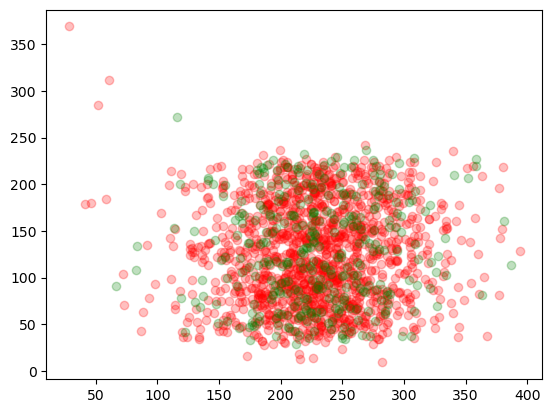

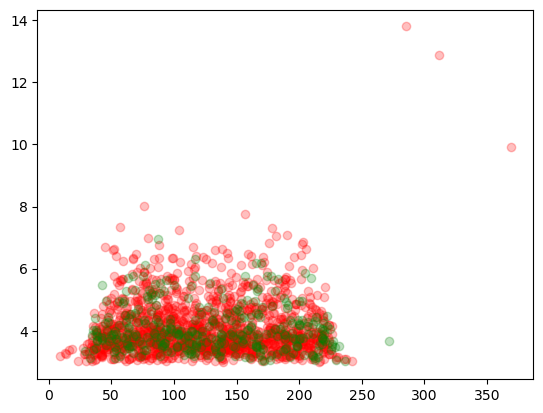

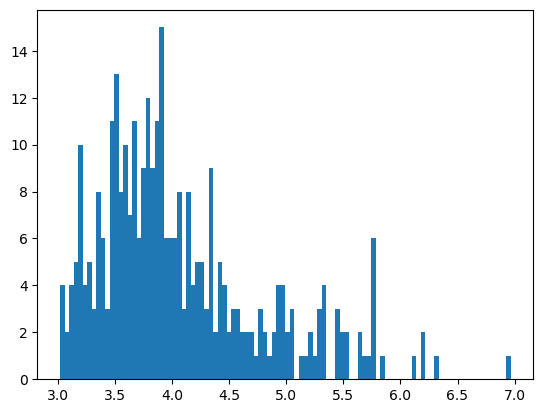

In [37]:

r1 = ComboRuns([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d15/spts.cxi' for i in range(431,436)])
r2 = ComboRuns([f'/home/tejvarmay/scattering_data/data/newdata/data00{i}_analysis_d5/spts.cxi' for i in range(431,436)])
_ = r1.filter_focused(r2)
#_ = r1.filter_intens(4,6)
#_ =r1.filter_y(100,200)
#_ =r1.filter_x(150,250)


plt.figure()
plt.scatter(r1.peak_xs[~r1.filter], r1.peak_ys[~r1.filter], color='r', alpha=0.25, label='removed')
plt.scatter(r1.peak_xs[r1.filter],  r1.peak_ys[r1.filter], color='g', alpha=0.25, label='included')


plt.figure()
plt.scatter(r1.peak_ys[~r1.filter], r1.peak_intens[~r1.filter]**(1/6), color='r', alpha=0.25, label='removed')
plt.scatter(r1.peak_ys[r1.filter],  r1.peak_intens[r1.filter]**(1/6), color='g', alpha=0.25, label='included')

plt.figure()
plt.hist(r1.peak_intens[r1.filter]**(1/6), bins=100)


###plot median intenstiy of filt